In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Cấu hình Style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs("../../reports/figures/risk_analysis", exist_ok=True)
save_path = "../../reports/figures/risk_analysis"

# Load dataset
df = pd.read_parquet("../../data/processed/clean_full")

print("Shape:", df.shape)
print(df["YEAR"].value_counts().sort_index())

Shape: (2525185, 82)
YEAR
2021    361428
2022    537902
2023    538837
2024    547271
2025    539747
Name: count, dtype: int64


In [135]:
# Mapping Tiếng Việt
vn_label = {
    'CANCELLED': 'Hủy chuyến',
    'DIVERTED': 'Chuyển hướng',
    'WEATHER_DELAY': 'Trễ do Thời tiết',
    'CARRIER_DELAY': 'Trễ do Hãng bay',
    'NAS_DELAY': 'Trễ do Hệ thống NAS',
    'LATE_AIRCRAFT_DELAY': 'Trễ dây chuyền (Máy bay đến muộn)',
    'A': 'Lỗi Hãng', 'B': 'Thời tiết', 'C': 'Hệ thống NAS', 'D': 'An ninh'
}

In [136]:
rename_cols = {
    # Time
    "YEAR": "Year",
    "MONTH": "Month",
    "DAY_OF_WEEK": "DayOfWeek",
    "DAY_OF_MONTH": "DayOfMonth",
    "FL_DATE": "FlightDate",
    # Airline
    "OP_CARRIER": "Airline",
    "OP_UNIQUE_CARRIER": "Airline_Code",
    # Airport
    "ORIGIN": "Origin_Airport",
    "DEST": "Destination_Airport",
    "ORIGIN_CITY_NAME": "Origin_City",
    "DEST_CITY_NAME": "Destination_City",
    # Route
    "ROUTE": "Route",
    "DISTANCE": "Distance",
    # Delay
    "ARR_DELAY": "Arrival_Delay",
    "DEP_DELAY": "Departure_Delay",
    "WEATHER_DELAY": "Weather_Delay",
    "CARRIER_DELAY": "Airline_Delay",
    "NAS_DELAY": "NAS_Delay",
    "SECURITY_DELAY": "Security_Delay",
    "LATE_AIRCRAFT_DELAY": "Late_Aircraft_Delay",
    # Time block
    "DEP_TIME_BLK": "Departure_Time_Block",
    # Risk
    "CANCELLATION_CODE": "Cancel_Code",
    "DIV_ARR_DELAY": "Diverted_Arrival_Delay"
}
df = df.rename(columns=rename_cols)
day_map = {
    0: "Mon", 1: "Tue", 2: "Wed",
    3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"
}

df["DayOfWeek"] = df["DayOfWeek"].map(day_map)

In [137]:
split_stats = pd.DataFrame({
    'Trạng thái': ['Tổng cộng (Full)', 'Hủy chuyến (Cancelled)', 'Chuyển hướng (Diverted)', 'Vận hành bình thường (Operated)'],
    'Số lượng dòng': [len(df_full), len(df_cancelled), len(df_diverted), len(df_operated)],
    'Tỷ lệ (%)': [
        100.0, 
        (len(df_cancelled)/len(df_full))*100, 
        (len(df_diverted)/len(df_full))*100, 
        (len(df_operated)/len(df_full))*100
    ]
})

split_stats['Tỷ lệ (%)'] = split_stats['Tỷ lệ (%)'].round(2)

display(split_stats)

,Trạng thái,Số lượng dòng,Tỷ lệ (%)
0,Tổng cộng (Full),2525185,100.00
1,Hủy chuyến (Cancelled),83899,3.32
2,Chuyển hướng (Diverted),5717,0.23
3,Vận hành bình thường (Operated),2435569,96.45


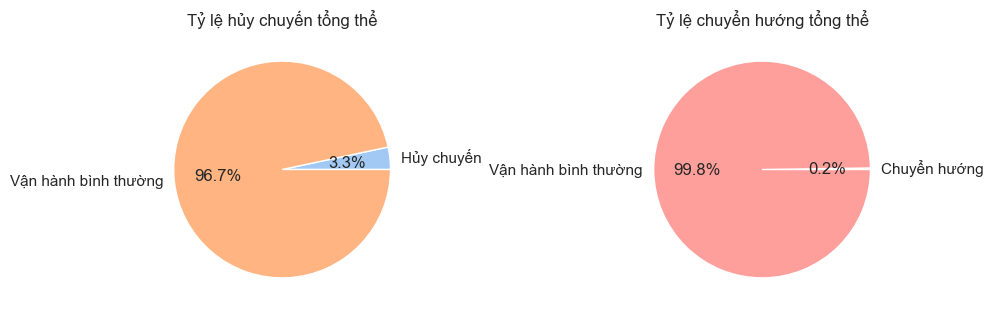

In [138]:
fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].pie([df_full["CANCELLED"].mean(), 1-df_full["CANCELLED"].mean()],
            labels=["Hủy chuyến","Vận hành bình thường"], autopct="%1.1f%%", colors=colors_bar[:2])
axes[0].set_title("Tỷ lệ hủy chuyến tổng thể")

axes[1].pie([df_full["DIVERTED"].mean(), 1-df_full["DIVERTED"].mean()],
            labels=["Chuyển hướng","Vận hành bình thường"], autopct="%1.1f%%", colors=colors_bar[2:4])
axes[1].set_title("Tỷ lệ chuyển hướng tổng thể")

plt.tight_layout()
plt.savefig(f"{save_path}/overall_cancel_divert.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\3367107101.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby("Year")[col].agg(['mean','count']).reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\3367107101.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby("Year")[col].agg(['mean','count']).reset_index()


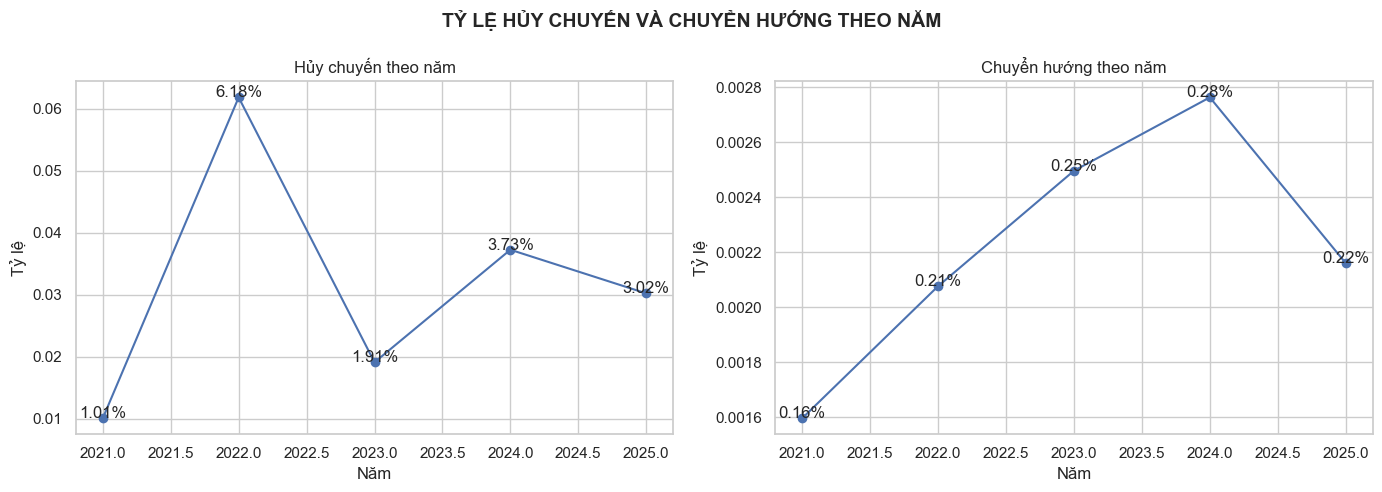

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

for i, col in enumerate(["CANCELLED", "DIVERTED"]):
    stats = df.groupby("Year")[col].agg(['mean','count']).reset_index()

    # Line (risk)
    axes[i].plot(stats["Year"], stats["mean"], marker='o')

    # Annotate
    for x, y in zip(stats["Year"], stats["mean"]):
        axes[i].text(x, y, f"{y:.2%}", ha='center')

    axes[i].set_title(f"{vn_label[col]} theo năm")
    axes[i].set_ylabel("Tỷ lệ")
    axes[i].set_xlabel("Năm")

plt.suptitle("TỶ LỆ HỦY CHUYẾN VÀ CHUYỂN HƯỚNG THEO NĂM", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{save_path}/cancelled_diverted_year.png")
plt.show()

Phân tích theo hãng bay và sân bay

C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\962561875.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=colors_bar)
C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\962561875.py:12: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=data.values, y=data.index, palette=colors_bar)


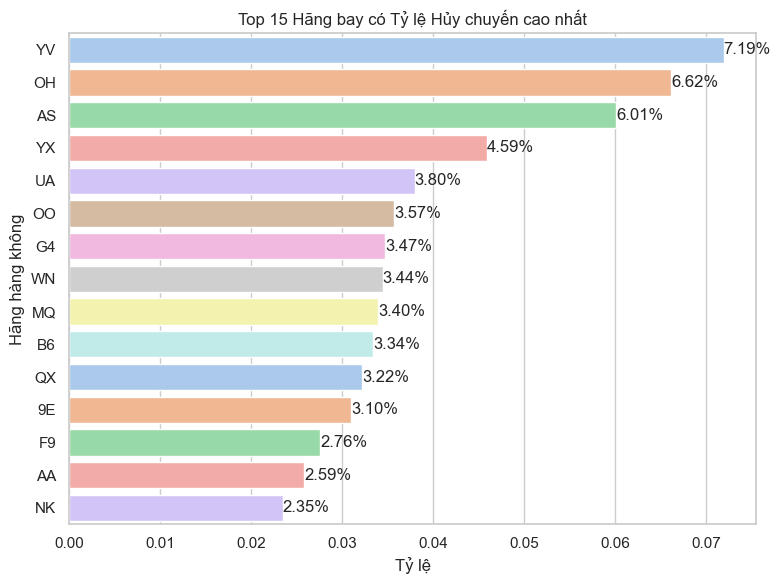

C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\962561875.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=colors_bar)
C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\962561875.py:12: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=data.values, y=data.index, palette=colors_bar)


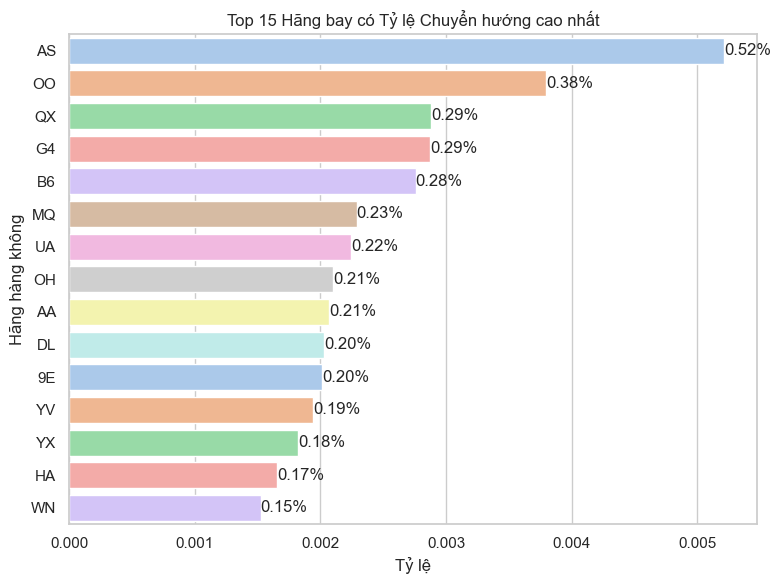

C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\962561875.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=colors_bar)
C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\962561875.py:26: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=data.values, y=data.index, palette=colors_bar)


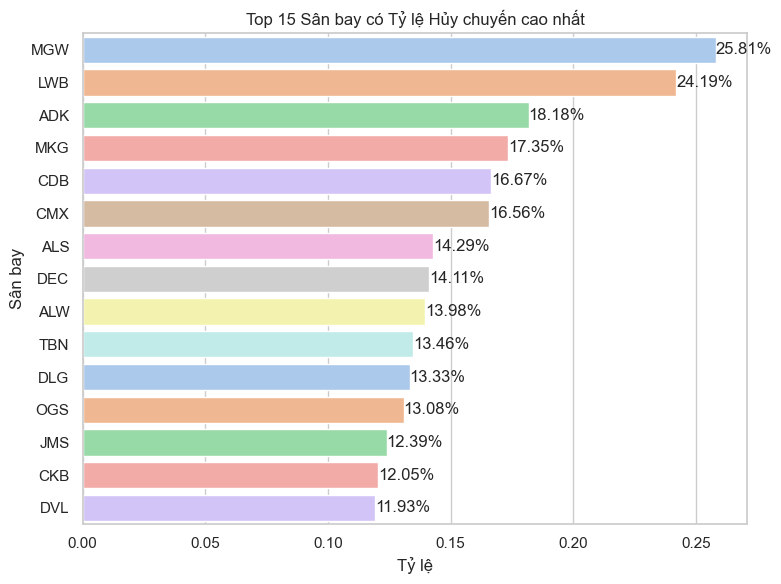

C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\962561875.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette=colors_bar)
C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\962561875.py:26: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=data.values, y=data.index, palette=colors_bar)


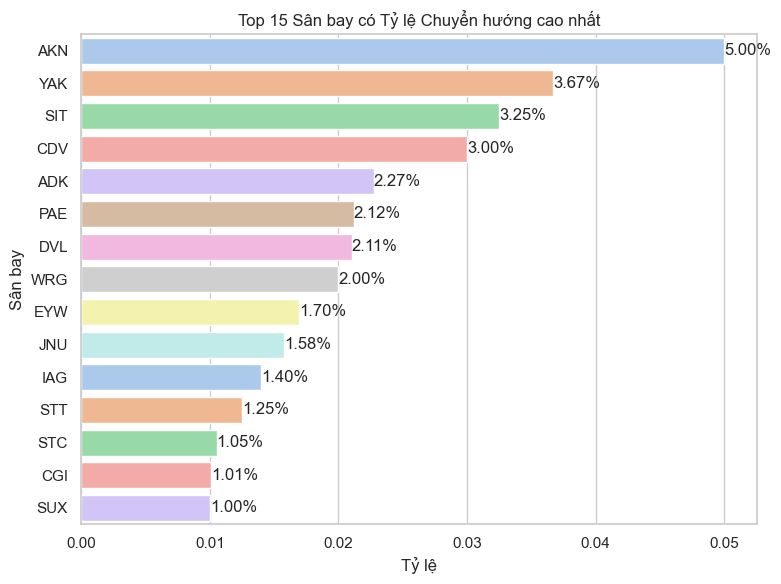

In [140]:
# 3.2. Phân tích theo hãng bay và sân bay
colors_bar = sns.color_palette("pastel")

# Lọc các hãng có ít nhất 10,000 chuyến để tránh nhiễu
major_airlines = df['Airline'].value_counts()[df['Airline'].value_counts() > 10000].index
df_major = df[df['Airline'].isin(major_airlines)].copy()

# Top Airlines
for col in ["CANCELLED", "DIVERTED"]:
    data = df_major.groupby("Airline")[col].mean().sort_values(ascending=False).head(15)
    plt.figure(figsize=(8,6))
    sns.barplot(x=data.values, y=data.index, palette=colors_bar)
    for i, v in enumerate(data.values):
        plt.text(v, i, f"{v:.2%}", va="center")
    plt.title(f"Top 15 Hãng bay có Tỷ lệ {vn_label[col]} cao nhất")
    plt.xlabel("Tỷ lệ")
    plt.ylabel("Hãng hàng không")
    plt.tight_layout()
    plt.savefig(f"{save_path}/top_airline_{col.lower()}.png")
    plt.show()

# Top Airports
for col in ["CANCELLED", "DIVERTED"]:
    data = df.groupby("Origin_Airport")[col].mean().sort_values(ascending=False).head(15)
    plt.figure(figsize=(8,6))
    sns.barplot(x=data.values, y=data.index, palette=colors_bar)
    for i, v in enumerate(data.values):
        plt.text(v, i, f"{v:.2%}", va="center")
    plt.title(f"Top 15 Sân bay có Tỷ lệ {vn_label[col]} cao nhất")
    plt.xlabel("Tỷ lệ")
    plt.ylabel("Sân bay")
    plt.tight_layout()
    plt.savefig(f"{save_path}/top_airport_{col.lower()}.png")
    plt.show()

Nguyên nhân hủy chuyến

C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\666386260.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_by_dist.index, y=cancel_by_dist.values, palette="Blues_d", ax=ax_dist)
C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\666386260.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


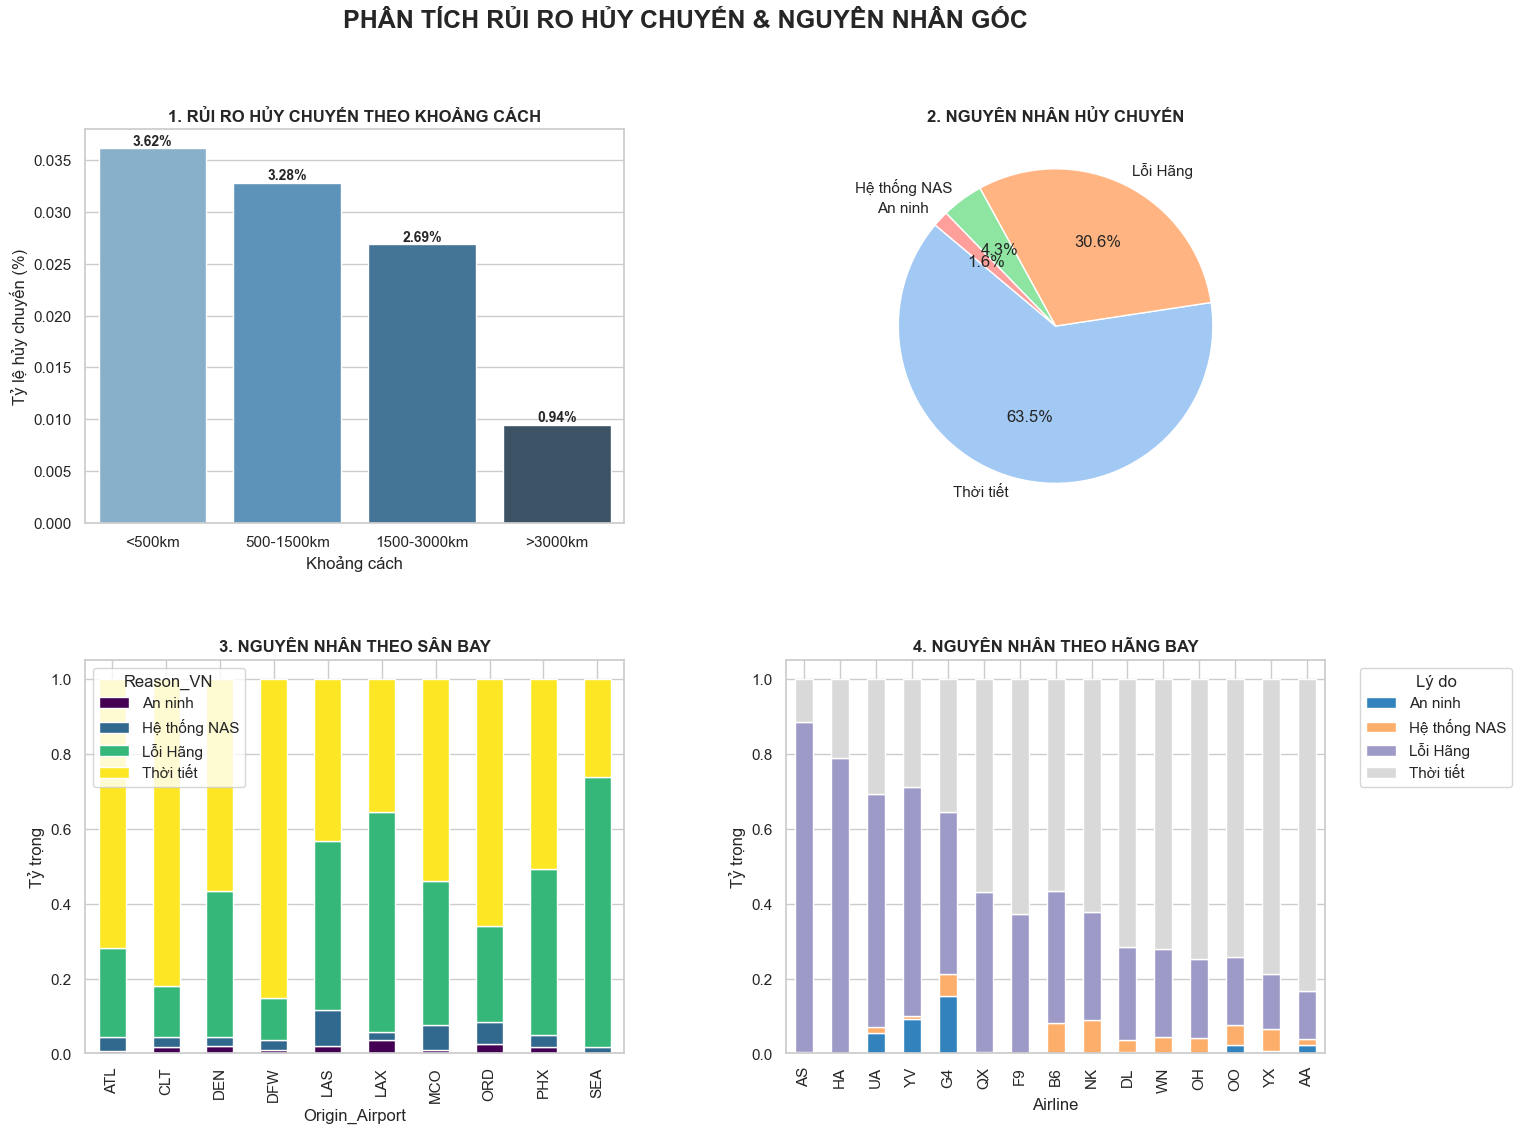

In [141]:

df['Distance_Group'] = pd.cut(df['Distance'], bins=[0, 500, 1500, 3000, 10000], labels=['<500km', '500-1500km', '1500-3000km', '>3000km'])
cancel_by_dist = df.groupby('Distance_Group', observed=False)['CANCELLED'].mean()

fig = plt.figure(figsize=(16, 12))
grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.35)

# Rủi ro theo khoảng cách
ax_dist = fig.add_subplot(grid[0, 0])

sns.barplot(x=cancel_by_dist.index, y=cancel_by_dist.values, palette="Blues_d", ax=ax_dist)

for p in ax_dist.patches:
    ax_dist.annotate(
        f'{p.get_height():.2%}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
ax_dist.set_title("1. RỦI RO HỦY CHUYẾN THEO KHOẢNG CÁCH", fontweight='bold')
ax_dist.set_ylabel("Tỷ lệ hủy chuyến (%)")
ax_dist.set_xlabel("Khoảng cách")

# Nguyên nhân hủy chuyến
ax_pie = fig.add_subplot(grid[0, 1])
reason_dist = df_cancelled["Reason_VN"].value_counts(normalize=True)
ax_pie.pie(reason_dist.values, labels=reason_dist.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"), startangle=140)
ax_pie.set_title("2. NGUYÊN NHÂN HỦY CHUYẾN", fontweight='bold')

# Phân tích theo sân bay
ax_apt = fig.add_subplot(grid[1, 0])
ct_apt = pd.crosstab(df_top_apt['Origin_Airport'], df_top_apt['Reason_VN'], normalize='index')
ct_apt.plot(kind='bar', stacked=True, ax=ax_apt, colormap='viridis')
ax_apt.set_title("3. NGUYÊN NHÂN THEO SÂN BAY", fontweight='bold')
ax_apt.set_ylabel("Tỷ trọng")

# Phân tích theo hãng bay
ax_air = fig.add_subplot(grid[1, 1])
ct_air = pd.crosstab(df_cancelled["Airline"], df_cancelled["Reason_VN"], normalize="index")
ct_air.sort_values(by='Lỗi Hãng', ascending=False).head(15).plot(kind='bar', stacked=True, ax=ax_air, colormap='tab20c')
ax_air.set_title("4. NGUYÊN NHÂN THEO HÃNG BAY", fontweight='bold')
ax_air.set_ylabel("Tỷ trọng")
ax_air.legend(title="Lý do", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.suptitle("PHÂN TÍCH RỦI RO HỦY CHUYẾN & NGUYÊN NHÂN GỐC", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{save_path}/risk_cancelled.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\2325674501.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_div.index, y=dist_div.values, ax=ax2, palette="Reds_r")


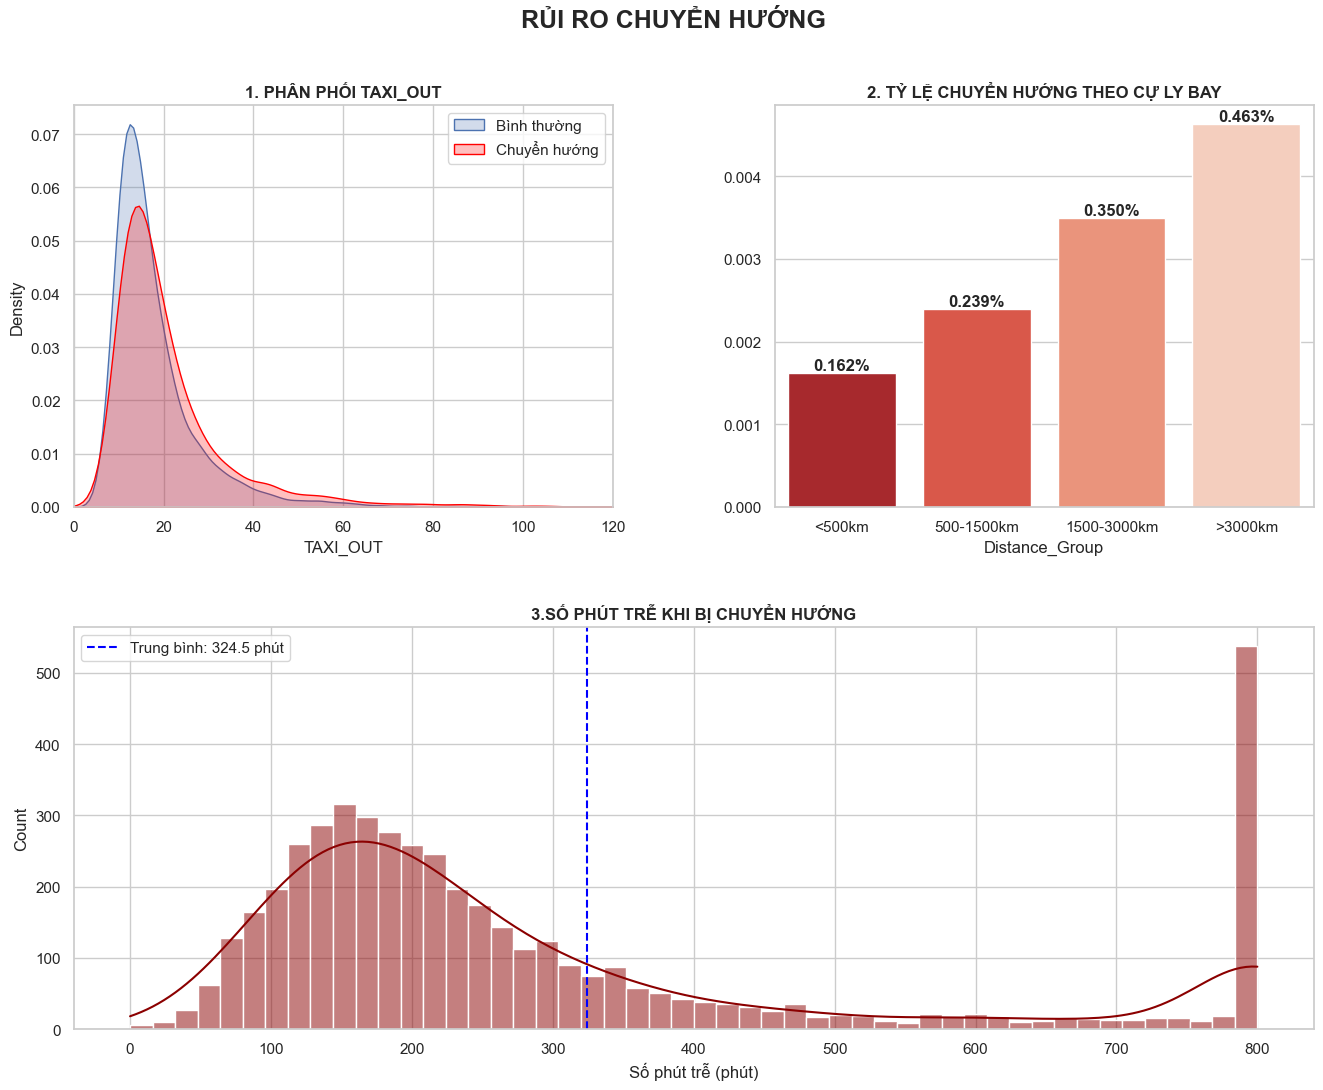

In [142]:
fig = plt.figure(figsize=(16, 12))
grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.3)

# 1. PHÂN PHỐI TAXI_OUT (Cảnh báo rủi ro sớm)
ax1 = fig.add_subplot(grid[0, 0])
sns.kdeplot(data=df[df['DIVERTED']==0].sample(10000), x='TAXI_OUT', label='Bình thường', fill=True, ax=ax1)
sns.kdeplot(data=df[df['DIVERTED']==1], x='TAXI_OUT', label='Chuyển hướng', fill=True, ax=ax1, color='red')
ax1.set_title("1. PHÂN PHỐI TAXI_OUT", fontweight='bold')
ax1.set_xlim(0, 120)
ax1.legend()

# 2. RỦI RO THEO KHOẢNG CÁCH (Chiến lược vận hành)
ax2 = fig.add_subplot(grid[0, 1])
dist_div = df.groupby('Distance_Group', observed=False)['DIVERTED'].mean()
sns.barplot(x=dist_div.index, y=dist_div.values, ax=ax2, palette="Reds_r")
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.3%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')
ax2.set_title("2. TỶ LỆ CHUYỂN HƯỚNG THEO CỰ LY BAY", fontweight='bold')

# 3. HỆ QUẢ: PHÂN PHỐI TRỄ CỦA CHUYẾN BAY CHUYỂN HƯỚNG (Impact)
ax3 = fig.add_subplot(grid[1, :])
# Lọc bỏ các giá trị outlier quá lớn để biểu đồ dễ nhìn hơn (>1000p)
div_delay = df[df['DIVERTED']==1]['Diverted_Arrival_Delay'].dropna()
sns.histplot(div_delay.clip(0, 800), bins=50, kde=True, ax=ax3, color='darkred')
ax3.axvline(div_delay.mean(), color='blue', linestyle='--', label=f'Trung bình: {div_delay.mean():.1f} phút')
ax3.set_title("3.SỐ PHÚT TRỄ KHI BỊ CHUYỂN HƯỚNG", fontweight='bold')
ax3.set_xlabel("Số phút trễ (phút)")
ax3.legend()

plt.suptitle("RỦI RO CHUYỂN HƯỚNG", fontsize=18, fontweight='bold', y=0.96)
plt.savefig(f"{save_path}/risk_diverted.png")
plt.show()

Phân tích theo khung giờ trong ngày

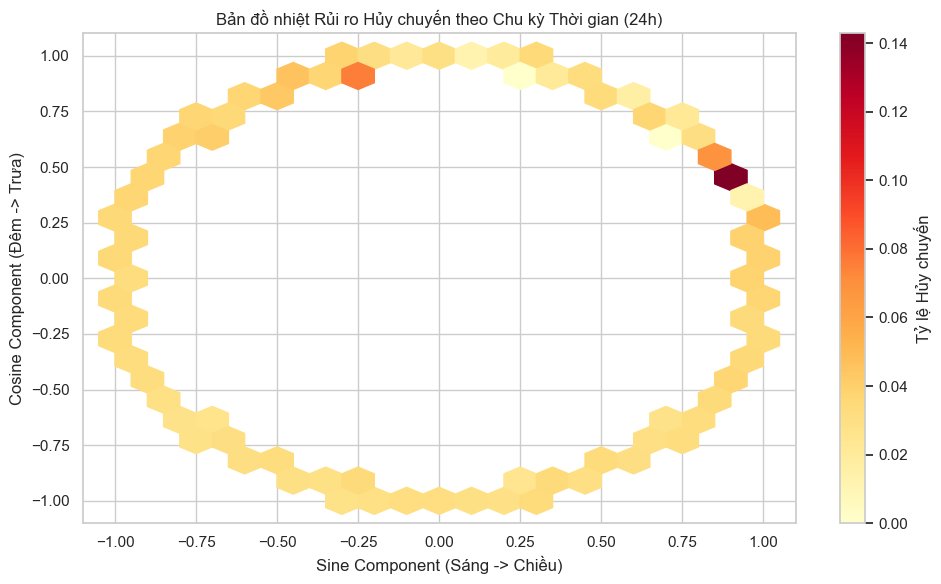

In [143]:

plt.figure(figsize=(10, 6))
plt.hexbin(df['CRS_DEP_SIN'], df['CRS_DEP_COS'], C=df['CANCELLED'], 
           gridsize=20, cmap='YlOrRd', reduce_C_function=np.mean)
plt.colorbar(label='Tỷ lệ Hủy chuyến')
plt.title("Bản đồ nhiệt Rủi ro Hủy chuyến theo Chu kỳ Thời gian (24h)")
plt.xlabel("Sine Component (Sáng -> Chiều)")
plt.ylabel("Cosine Component (Đêm -> Trưa)")
plt.tight_layout()
plt.savefig("../../reports/figures/risk_analysis/cyclical_risk_map.png")
plt.show()

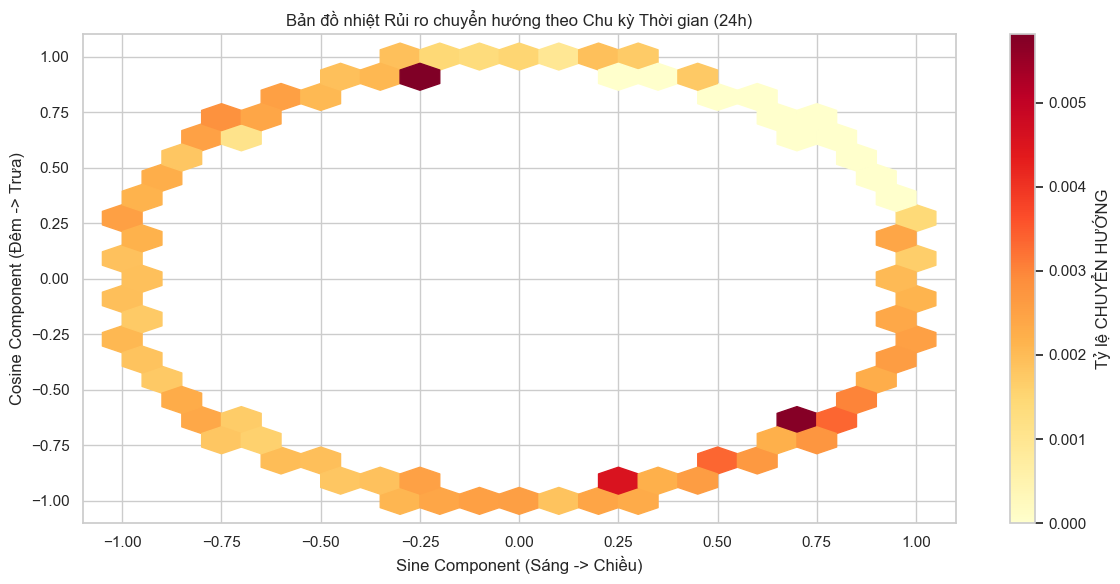

In [144]:
plt.hexbin(df['CRS_DEP_SIN'], df['CRS_DEP_COS'], C=df['DIVERTED'], gridsize=20, cmap='YlOrRd', reduce_C_function=np.mean)
plt.colorbar(label='Tỷ lệ CHUYỂN HƯỚNG')
plt.title("Bản đồ nhiệt Rủi ro chuyển hướng theo Chu kỳ Thời gian (24h)")
plt.xlabel("Sine Component (Sáng -> Chiều)")
plt.ylabel("Cosine Component (Đêm -> Trưa)")
plt.tight_layout()
plt.savefig("../../reports/figures/risk_analysis/cyclical_risk_map.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\1379269549.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(time_insight.index, rotation=45)


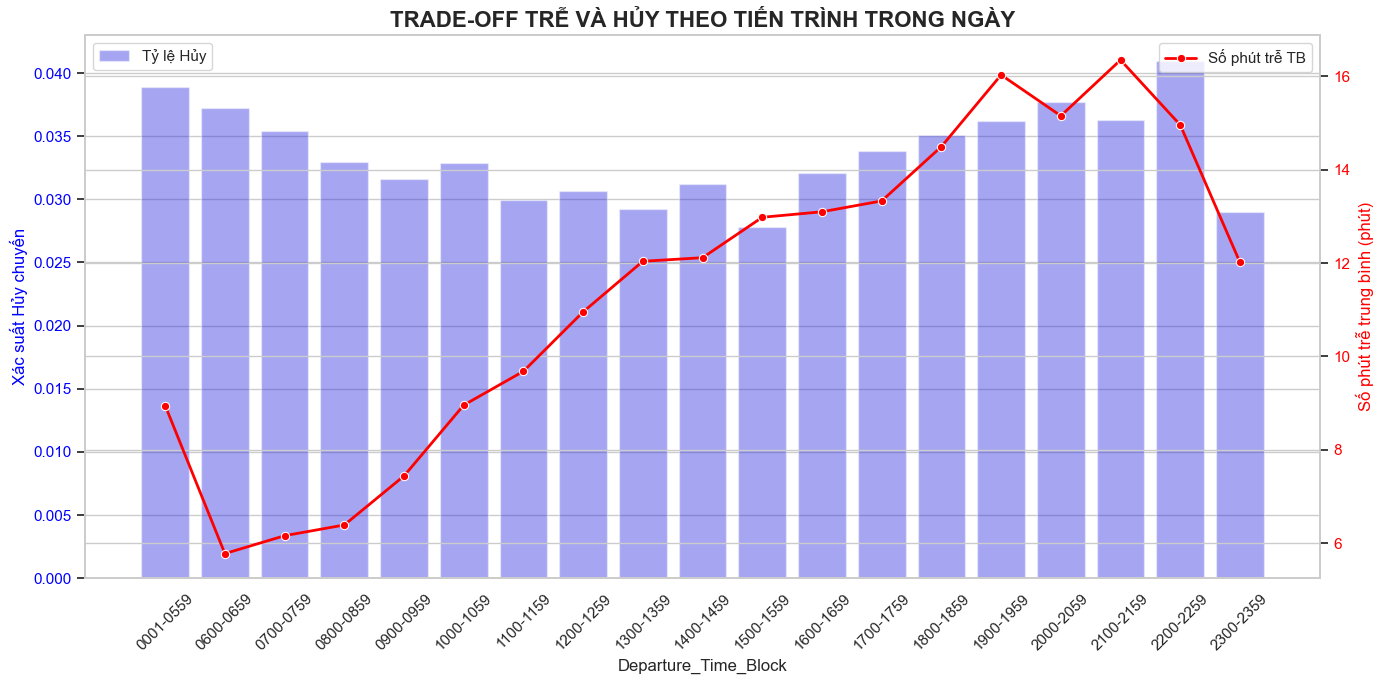

In [145]:
# 1. Tính toán tỷ lệ hủy và trễ trung bình theo khung giờ
time_insight = df.groupby('Departure_Time_Block').agg({ 'CANCELLED': 'mean', 'Departure_Delay': 'mean'}).sort_index()

# 2. Vẽ biểu đồ kép
fig, ax1 = plt.subplots(figsize=(14, 7))
# Trục 1: Tỷ lệ Hủy chuyến (Bar chart)
sns.barplot(x=time_insight.index, y=time_insight['CANCELLED'], ax=ax1, alpha=0.4, color='blue', label='Tỷ lệ Hủy')
ax1.set_ylabel('Xác suất Hủy chuyến', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Trục 2: Số phút trễ trung bình (Line chart)
ax2 = ax1.twinx()
sns.lineplot(x=time_insight.index, y=time_insight['Departure_Delay'], ax=ax2, marker='o', color='red', linewidth=2, label='Số phút trễ TB')
ax2.set_ylabel('Số phút trễ trung bình (phút)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('TRADE-OFF TRỄ VÀ HỦY THEO TIẾN TRÌNH TRONG NGÀY', fontsize=16, fontweight='bold')
ax1.set_xticklabels(time_insight.index, rotation=45)
fig.tight_layout()
plt.savefig(f"{save_path}/trade_off_delay&cancelled.png")
plt.show()

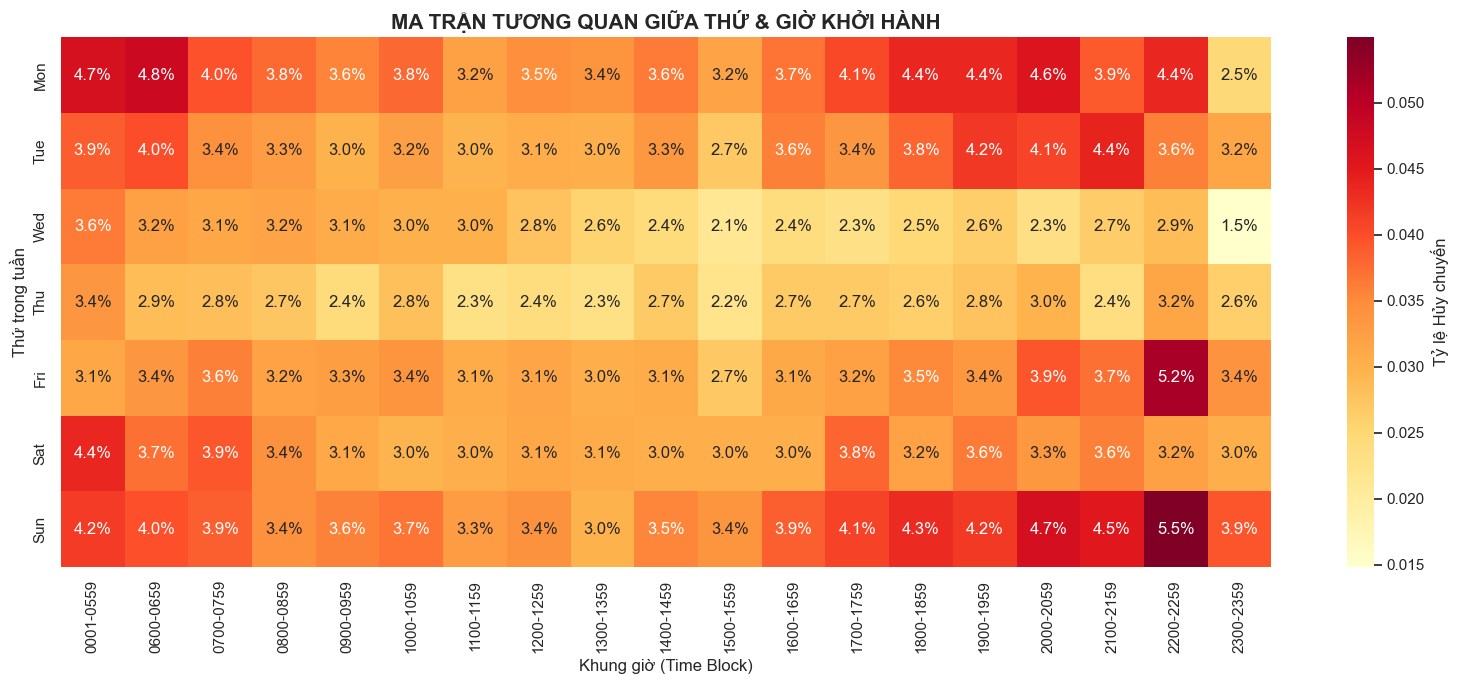

In [146]:
order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot_risk = df.pivot_table(index='DayOfWeek', columns='Departure_Time_Block', values='CANCELLED', aggfunc='mean')

pivot_risk = pivot_risk.reindex(order).astype(float) 
pivot_risk = pivot_risk.fillna(0)
plt.figure(figsize=(16, 7))
sns.heatmap(pivot_risk, annot=True, fmt=".1%", cmap="YlOrRd", cbar_kws={'label': 'Tỷ lệ Hủy chuyến'})
plt.title("MA TRẬN TƯƠNG QUAN GIỮA THỨ & GIỜ KHỞI HÀNH", fontsize=15, fontweight='bold')
plt.xlabel("Khung giờ (Time Block)")
plt.ylabel("Thứ trong tuần")
plt.tight_layout()
plt.savefig(f"{save_path}/heatmap_cancelled.png")
plt.show()

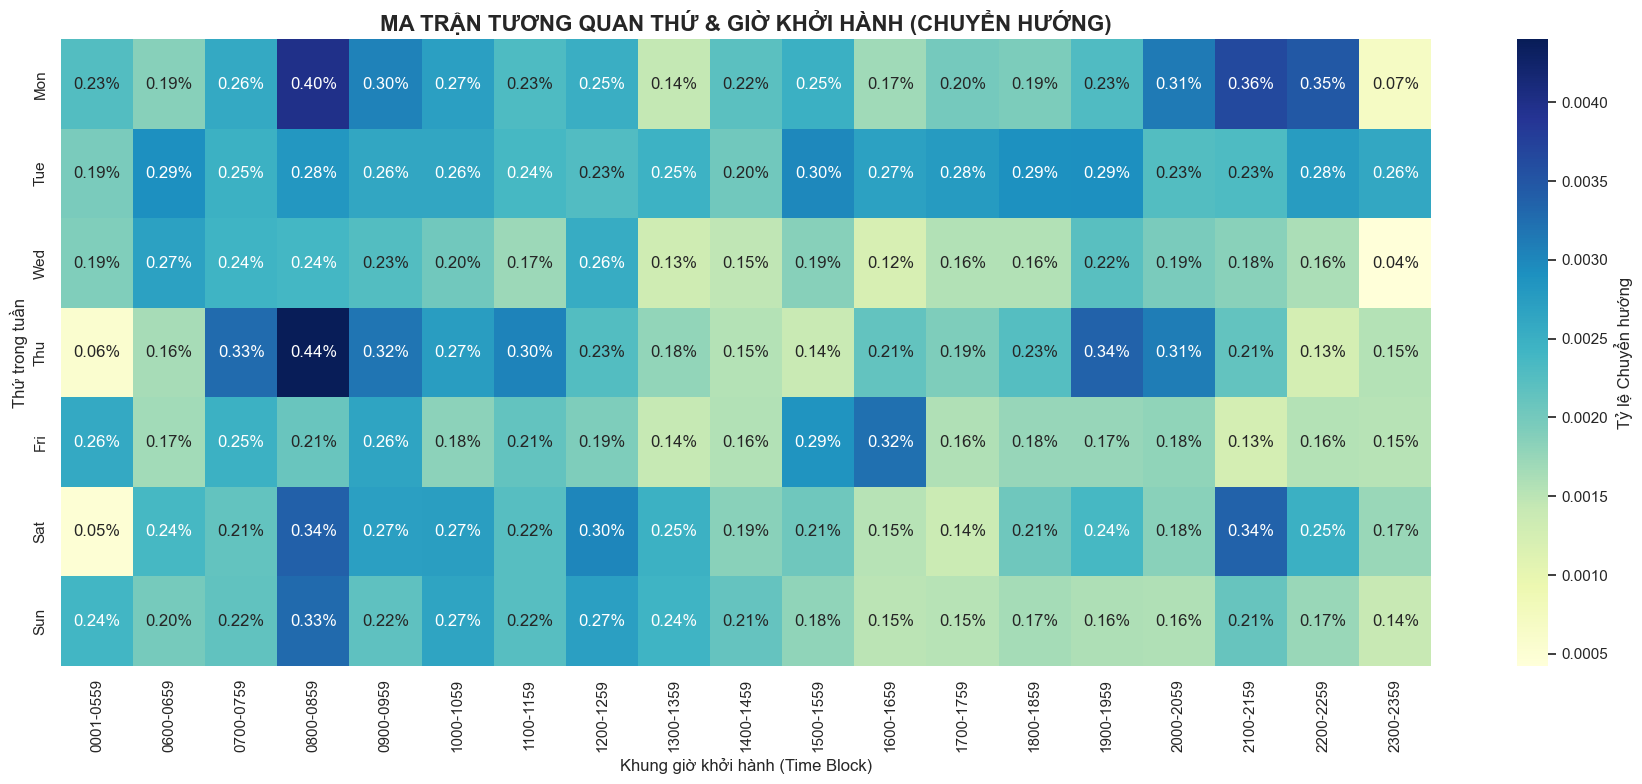

In [149]:
order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot_diverted = df.pivot_table(index='DayOfWeek', columns='Departure_Time_Block', values='DIVERTED',aggfunc='mean')
pivot_diverted = pivot_diverted.reindex(order).astype(float).fillna(0)
plt.figure(figsize=(18, 8))
sns.heatmap(pivot_diverted, annot=True, fmt=".2%", cmap="YlGnBu", cbar_kws={'label': 'Tỷ lệ Chuyển hướng'})
plt.title("MA TRẬN TƯƠNG QUAN THỨ & GIỜ KHỞI HÀNH (CHUYỂN HƯỚNG)", fontsize=16, fontweight='bold')
plt.xlabel("Khung giờ khởi hành (Time Block)")
plt.ylabel("Thứ trong tuần")
plt.tight_layout()

plt.savefig(f"{save_path}/heatmap_diverted.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_8256\1282333286.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(time_risk.index, rotation=45)


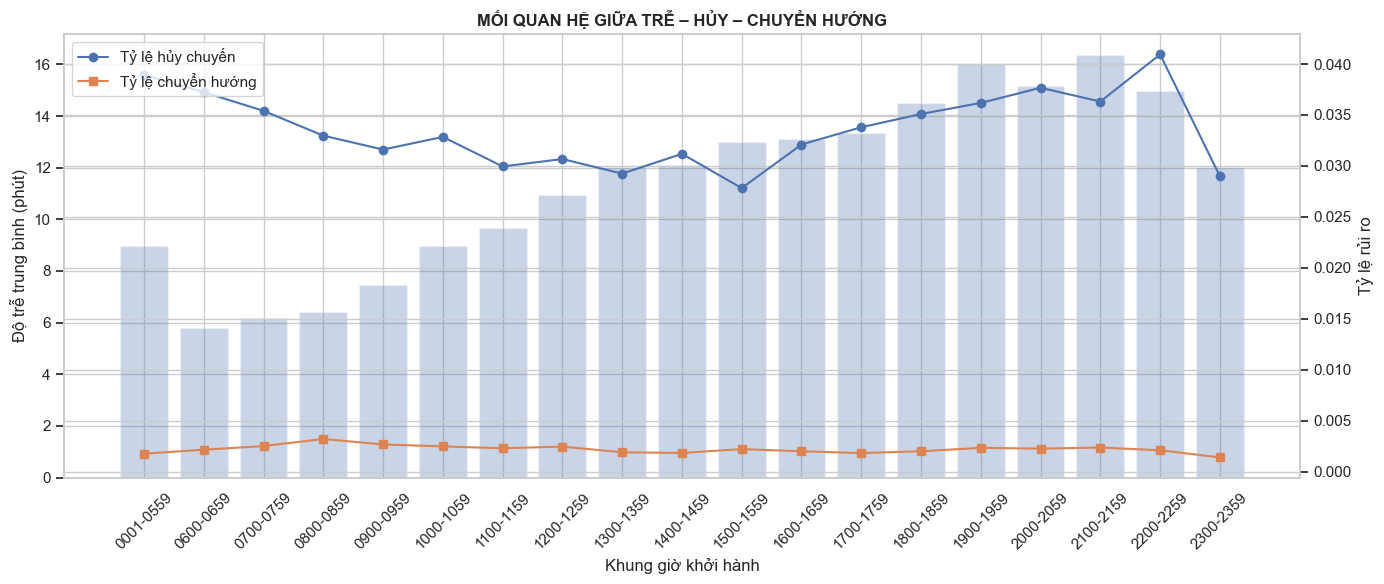

In [148]:
time_risk = df.groupby("Departure_Time_Block").agg({"CANCELLED": "mean", "DIVERTED": "mean", "Departure_Delay": "mean"}).sort_index()
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.bar(time_risk.index, time_risk["Departure_Delay"], alpha=0.3)
ax1.set_ylabel("Độ trễ trung bình (phút)")
ax1.set_xlabel("Khung giờ khởi hành")
ax1.set_xticklabels(time_risk.index, rotation=45)

ax2 = ax1.twinx()
ax2.plot(time_risk.index, time_risk["CANCELLED"], marker='o', label="Tỷ lệ hủy chuyến")
ax2.plot(time_risk.index, time_risk["DIVERTED"], marker='s', label="Tỷ lệ chuyển hướng")

ax2.set_ylabel("Tỷ lệ rủi ro")
ax2.legend(loc="upper left")

plt.title("MỐI QUAN HỆ GIỮA TRỄ – HỦY – CHUYỂN HƯỚNG", fontweight='bold')
plt.tight_layout()
plt.savefig(f"{save_path}/system_behavior_delay_cancel_divert.png", dpi=300, bbox_inches='tight')
plt.show()